In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/emg-models-v1/intent_best.pt
/kaggle/input/datasets/jorgeoc/emg-models-v1/juez_calidad_best.pt
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/Y_0014.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/Y_0020.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0041.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v1/intent_dataset/X_0000.npy
/kaggle/input/datasets/jorg

In [2]:
# =========================
# CELDA 1: Imports
# =========================
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


In [3]:
# =========================
# CELDA: Modelos + inferencia stream + warmup
# =========================
import os
import glob
import time
import numpy as np
import torch
import torch.nn as nn

THR_INTENT = 0.50
THR_QUALITY = 0.50
WIN = 400

# ---------- Arquitecturas ----------
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.head_score = nn.Linear(32, 1)
        self.head_label = nn.Linear(32, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y

# ---------- Utils ----------
def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

# ---------- Device ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------- Buscar modelos ----------
candidate_model_dirs = []

for p in glob.glob("/kaggle/input/**/intent_binary_best.pt", recursive=True):
    model_dir = os.path.dirname(p)
    q_path = os.path.join(model_dir, "quality_judge_best.pt")
    r_path = os.path.join(model_dir, "restorer_best.pt")
    if os.path.exists(q_path) and os.path.exists(r_path):
        candidate_model_dirs.append(model_dir)

print("Candidatos de modelos:")
for c in candidate_model_dirs:
    print(" -", c)

if not candidate_model_dirs:
    raise FileNotFoundError("No encontré los modelos .pt")

MODELS_DIR = candidate_model_dirs[0]
print("Usando MODELS_DIR:", MODELS_DIR)

# ---------- Cargar modelos ----------
intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "intent_binary_best.pt"), map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "quality_judge_best.pt"), map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "restorer_best.pt"), map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")

# ---------- Inferencia stream ----------
@torch.no_grad()
def infer_window_stream(window_1d, thr_intent=0.50, thr_quality=0.50):
    xb = torch.tensor(window_1d[None, None, :], dtype=torch.float32, device=device)

    t0 = time.perf_counter()

    intent_logits = intent_model(xb)
    p_intent = float(torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)[0])

    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = float(q_score_pred.cpu().numpy().reshape(-1)[0])
    q_prob_good = float(torch.sigmoid(q_logit).cpu().numpy().reshape(-1)[0])

    if p_intent < thr_intent:
        decision = "REJECT"
        reason = "no_intent_detected"
        out = window_1d.copy()
    elif q_prob_good >= thr_quality:
        decision = "OK"
        reason = "signal_quality_good_enough"
        out = window_1d.copy()
    else:
        decision = "RESTORE"
        reason = "intent_detected_and_quality_bad"
        out = restorer_model(xb).cpu().numpy()[0, 0]

    latency_ms = (time.perf_counter() - t0) * 1000.0

    msg = f"{decision},{p_intent:.3f},{q_prob_good:.3f},{q_score_pred:.3f},{latency_ms:.3f}"

    return {
        "decision": decision,
        "reason": reason,
        "p_intent": p_intent,
        "q_score_pred": q_score_pred,
        "q_prob_good": q_prob_good,
        "latency_ms": latency_ms,
        "message": msg,
        "output_window": out.astype(np.float32),
    }

# ---------- Warmup ----------
dummy = np.zeros(WIN, dtype=np.float32)
for _ in range(3):
    _ = infer_window_stream(dummy, thr_intent=THR_INTENT, thr_quality=THR_QUALITY)

print("Warmup completado.")


device: cpu
Candidatos de modelos:
 - /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1
Usando MODELS_DIR: /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1
Modelos cargados correctamente.
Warmup completado.


In [4]:
# =========================
# CELDA 3: Cargar modelos
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

candidate_model_dirs = []

for p in glob.glob("/kaggle/input/**/intent_binary_best.pt", recursive=True):
    model_dir = os.path.dirname(p)
    q_path = os.path.join(model_dir, "quality_judge_best.pt")
    r_path = os.path.join(model_dir, "restorer_best.pt")
    if os.path.exists(q_path) and os.path.exists(r_path):
        candidate_model_dirs.append(model_dir)

print("Candidatos de modelos:")
for c in candidate_model_dirs:
    print(" -", c)

if not candidate_model_dirs:
    raise FileNotFoundError("No encontré los modelos .pt")

MODELS_DIR = candidate_model_dirs[0]
print("Usando MODELS_DIR:", MODELS_DIR)

intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "intent_binary_best.pt"), map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "quality_judge_best.pt"), map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "restorer_best.pt"), map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")


device: cpu
Candidatos de modelos:
 - /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1
Usando MODELS_DIR: /kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1
Modelos cargados correctamente.


In [5]:
# =========================
# CELDA 4: Utilidades
# =========================
THR_INTENT = 0.50
THR_QUALITY = 0.50
WIN = 400

def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def snr_db(clean, noisy):
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return float(10 * np.log10(ps / pn))

def windows_1d(sig, win=400, stride=200):
    idxs = np.arange(0, len(sig) - win + 1, stride)
    return np.stack([sig[i:i+win] for i in idxs], axis=0)[:, None, :].astype(np.float32)


In [6]:
# =========================
# CELDA 5: Inferencia streaming
# =========================
@torch.no_grad()
def infer_window_stream(window_1d, thr_intent=0.50, thr_quality=0.50):
    xb = torch.tensor(window_1d[None, None, :], dtype=torch.float32, device=device)

    t0 = time.perf_counter()

    intent_logits = intent_model(xb)
    p_intent = float(torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)[0])

    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = float(q_score_pred.cpu().numpy().reshape(-1)[0])
    q_prob_good = float(torch.sigmoid(q_logit).cpu().numpy().reshape(-1)[0])

    if p_intent < thr_intent:
        decision = "REJECT"
        reason = "no_intent_detected"
        out = window_1d.copy()
    elif q_prob_good >= thr_quality:
        decision = "OK"
        reason = "signal_quality_good_enough"
        out = window_1d.copy()
    else:
        decision = "RESTORE"
        reason = "intent_detected_and_quality_bad"
        out = restorer_model(xb).cpu().numpy()[0, 0]

    latency_ms = (time.perf_counter() - t0) * 1000.0

    msg = f"{decision},{p_intent:.3f},{q_prob_good:.3f},{q_score_pred:.3f},{latency_ms:.3f}"

    return {
        "decision": decision,
        "reason": reason,
        "p_intent": p_intent,
        "q_score_pred": q_score_pred,
        "q_prob_good": q_prob_good,
        "latency_ms": latency_ms,
        "message": msg,
        "output_window": out.astype(np.float32),
    }


In [7]:
# =========================
# CELDA 6: Warmup
# =========================
dummy = np.zeros(WIN, dtype=np.float32)
for _ in range(3):
    _ = infer_window_stream(dummy, thr_intent=THR_INTENT, thr_quality=THR_QUALITY)

print("Warmup completado.")


Warmup completado.


In [8]:
# =========================
# CELDA 7: Fuente mock
# =========================
MOCK_SOURCE = "dataset"
# opciones:
# "dataset"
# "synthetic"

x_stream = None
x_clean_ref = None


In [9]:
# =========================
# CELDA 8: Fuente dataset
# =========================
if MOCK_SOURCE == "dataset":
    candidate_dirs = []
    for p in glob.glob("/kaggle/input/**/restoration_dataset", recursive=True):
        if os.path.isdir(p):
            xcorr = glob.glob(os.path.join(p, "Xcorr_*.npy"))
            xclean = glob.glob(os.path.join(p, "Xclean_*.npy"))
            if len(xcorr) > 0 and len(xclean) > 0:
                candidate_dirs.append(p)

    if not candidate_dirs:
        raise FileNotFoundError("No encontré restoration_dataset")

    RDIR = candidate_dirs[0]
    Xcorr_files = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
    Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))

    x_stream = np.load(Xcorr_files[0])[:300]
    x_clean_ref = np.load(Xclean_files[0])[:300]

    print("Usando fuente dataset")
    print("x_stream:", x_stream.shape)


Usando fuente dataset
x_stream: (300, 1, 400)


In [10]:
# =========================
# CELDA 9: Fuente sintética
# =========================
def make_synthetic_sequence(num_windows=30, T=400, seed=123):
    rng = np.random.default_rng(seed)
    x_clean_list = []
    x_corr_list = []

    for i in range(num_windows):
        t = np.linspace(0, 1, T)

        if i % 4 == 0:
            clean = np.zeros(T, dtype=np.float32)
            clean += 0.02 * rng.normal(size=T).astype(np.float32)
        else:
            env = np.exp(-0.5 * ((t - 0.5) / 0.12)**2)
            carrier = np.sin(2*np.pi*35*t) + 0.5*np.sin(2*np.pi*70*t)
            clean = (1.8 * env * carrier).astype(np.float32)

        noisy = clean.copy()
        noisy += rng.normal(0, 0.25, size=T).astype(np.float32)

        if i % 3 == 0:
            noisy += (0.5 * np.sin(2*np.pi*1.2*t)).astype(np.float32)

        if i % 5 == 0:
            start = 120
            noisy[start:start+50] = 0.0

        x_clean_list.append(clean[None, :])
        x_corr_list.append(noisy[None, :])

    x_clean = np.stack(x_clean_list).astype(np.float32)
    x_corr = np.stack(x_corr_list).astype(np.float32)
    return x_clean, x_corr

if MOCK_SOURCE == "synthetic":
    x_clean_ref, x_stream = make_synthetic_sequence(num_windows=30)
    print("Usando fuente sintética")
    print("x_stream:", x_stream.shape)


In [11]:
# =========================
# CELDA 10: Simulación stream
# =========================
if x_stream is None:
    raise ValueError("No se cargó ninguna fuente mock.")

rows = []
x_out = []

for i in range(len(x_stream)):
    res = infer_window_stream(
        x_stream[i, 0],
        thr_intent=THR_INTENT,
        thr_quality=THR_QUALITY
    )

    rows.append({
        "idx": i,
        "decision": res["decision"],
        "reason": res["reason"],
        "p_intent": res["p_intent"],
        "q_score_pred": res["q_score_pred"],
        "q_prob_good": res["q_prob_good"],
        "latency_ms": res["latency_ms"],
        "message": res["message"],
    })
    x_out.append(res["output_window"][None, :])

df_stream = pd.DataFrame(rows)
x_out = np.stack(x_out).astype(np.float32)

print(df_stream.head())


   idx decision                           reason  p_intent  q_score_pred  \
0    0  RESTORE  intent_detected_and_quality_bad  0.885436      0.365641   
1    1   REJECT               no_intent_detected  0.278118      0.950326   
2    2       OK       signal_quality_good_enough  0.940655      0.999781   
3    3  RESTORE  intent_detected_and_quality_bad  0.620910      0.423496   
4    4       OK       signal_quality_good_enough  0.924139      0.999703   

   q_prob_good  latency_ms                          message  
0     0.000270    7.456960  RESTORE,0.885,0.000,0.366,7.457  
1     0.996506    3.367458   REJECT,0.278,0.997,0.950,3.367  
2     0.999999    2.816080       OK,0.941,1.000,1.000,2.816  
3     0.004911    3.349599  RESTORE,0.621,0.005,0.423,3.350  
4     1.000000    2.605222       OK,0.924,1.000,1.000,2.605  


In [12]:
# =========================
# CELDA 11: Resumen stream
# =========================
print("Conteo de decisiones:")
print(df_stream["decision"].value_counts(dropna=False))
print()

print("Razones:")
print(df_stream["reason"].value_counts(dropna=False))
print()

lat = df_stream["latency_ms"].values
lat_wo_first = lat[1:] if len(lat) > 1 else lat

print("Latencia (incluyendo primera):")
print("mean:", float(np.mean(lat)))
print("median:", float(np.median(lat)))
print("min/max:", float(np.min(lat)), float(np.max(lat)))
print()

print("Latencia (sin primera ventana):")
print("mean:", float(np.mean(lat_wo_first)))
print("median:", float(np.median(lat_wo_first)))
print("p90:", float(np.percentile(lat_wo_first, 90)))
print("p95:", float(np.percentile(lat_wo_first, 95)))
print("min/max:", float(np.min(lat_wo_first)), float(np.max(lat_wo_first)))


Conteo de decisiones:
decision
OK         153
REJECT      79
RESTORE     68
Name: count, dtype: int64

Razones:
reason
signal_quality_good_enough         153
no_intent_detected                  79
intent_detected_and_quality_bad     68
Name: count, dtype: int64

Latencia (incluyendo primera):
mean: 2.66849113333213
median: 2.4769784999989497
min/max: 2.3265819999096493 7.456960000013169

Latencia (sin primera ventana):
mean: 2.6524761872897185
median: 2.476924000006875
p90: 3.193239800043557
p95: 3.261183800066191
min/max: 2.3265819999096493 4.025307999995675


In [13]:
# =========================
# CELDA 12: Métricas con referencia
# =========================
if x_clean_ref is not None:
    metrics_rows = []
    for i in range(len(x_stream)):
        clean = x_clean_ref[i, 0]
        corr = x_stream[i, 0]
        out = x_out[i, 0]

        metrics_rows.append({
            "idx": i,
            "decision": df_stream.iloc[i]["decision"],
            "reason": df_stream.iloc[i]["reason"],
            "mae_before": mae_np(clean, corr),
            "mae_after": mae_np(clean, out),
            "snr_before": snr_db(clean, corr),
            "snr_after": snr_db(clean, out),
            "improved_mae": mae_np(clean, out) < mae_np(clean, corr),
            "improved_snr": snr_db(clean, out) > snr_db(clean, corr),
        })

    df_metrics = pd.DataFrame(metrics_rows)

    print("Promedios globales:")
    print(df_metrics[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())
    print()

    dfr = df_metrics[df_metrics["decision"] == "RESTORE"]
    if len(dfr):
        print("Solo restauradas:")
        print(dfr[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())
        print("Frac mejora MAE:", dfr["improved_mae"].mean())
        print("Frac mejora SNR:", dfr["improved_snr"].mean())
else:
    print("No hay referencia limpia.")


Promedios globales:
mae_before     0.904246
mae_after      0.496943
snr_before    25.232407
snr_after     27.693351
dtype: float64

Solo restauradas:
mae_before     2.368426
mae_after      0.571504
snr_before     6.296268
snr_after     17.153373
dtype: float64
Frac mejora MAE: 0.9558823529411765
Frac mejora SNR: 0.9705882352941176


In [14]:
# =========================
# CELDA 13: Mensajes seriales mock
# =========================
for i in range(min(10, len(df_stream))):
    print(df_stream.iloc[i]["message"])


RESTORE,0.885,0.000,0.366,7.457
REJECT,0.278,0.997,0.950,3.367
OK,0.941,1.000,1.000,2.816
RESTORE,0.621,0.005,0.423,3.350
OK,0.924,1.000,1.000,2.605
OK,0.965,1.000,1.000,2.517
RESTORE,0.886,0.124,0.512,3.371
OK,0.729,0.999,0.980,2.560
OK,0.826,1.000,0.998,2.449
OK,0.791,1.000,0.999,2.448


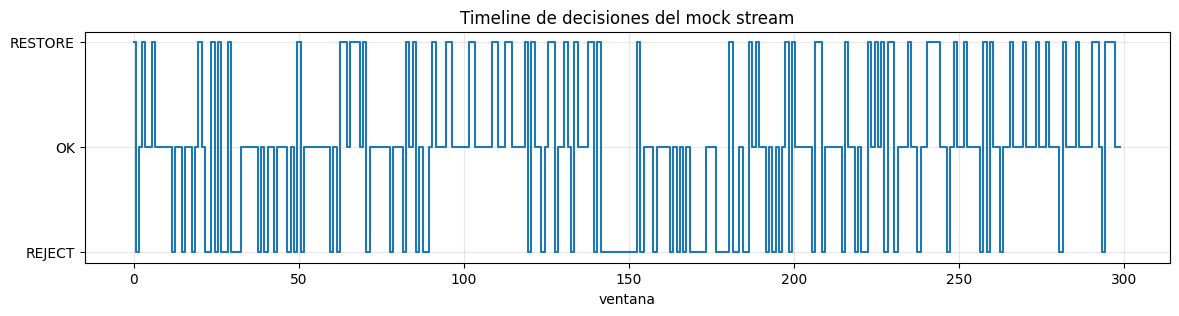

In [15]:
# =========================
# CELDA 14: Timeline decisiones
# =========================
decision_map = {"REJECT": 0, "OK": 1, "RESTORE": 2}
timeline = df_stream["decision"].map(decision_map).values

plt.figure(figsize=(14,3))
plt.plot(timeline, drawstyle="steps-mid")
plt.yticks([0,1,2], ["REJECT", "OK", "RESTORE"])
plt.title("Timeline de decisiones del mock stream")
plt.xlabel("ventana")
plt.grid(True, alpha=0.3)
plt.show()


idx=0
message=RESTORE,0.885,0.000,0.366,7.457
reason=intent_detected_and_quality_bad
latency_ms=7.457



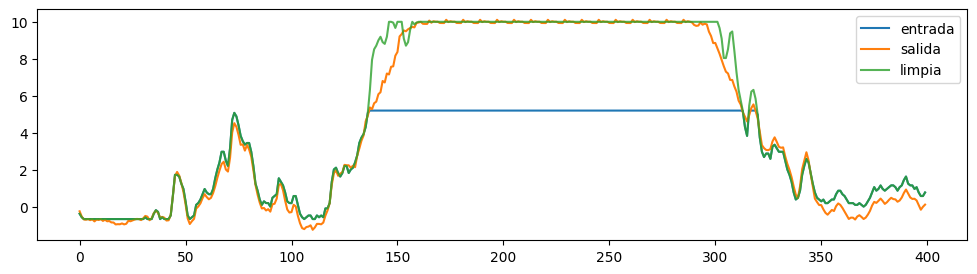

idx=1
message=REJECT,0.278,0.997,0.950,3.367
reason=no_intent_detected
latency_ms=3.367



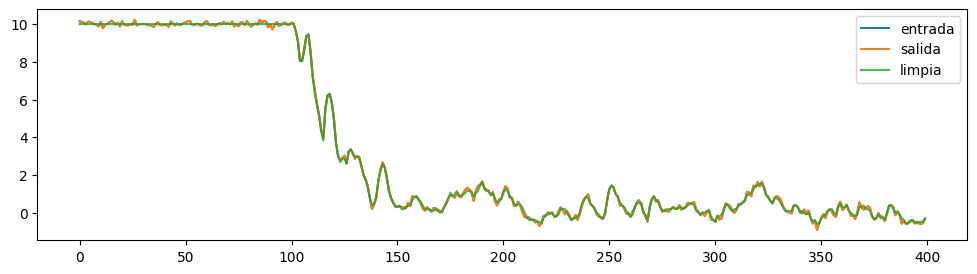

idx=2
message=OK,0.941,1.000,1.000,2.816
reason=signal_quality_good_enough
latency_ms=2.816



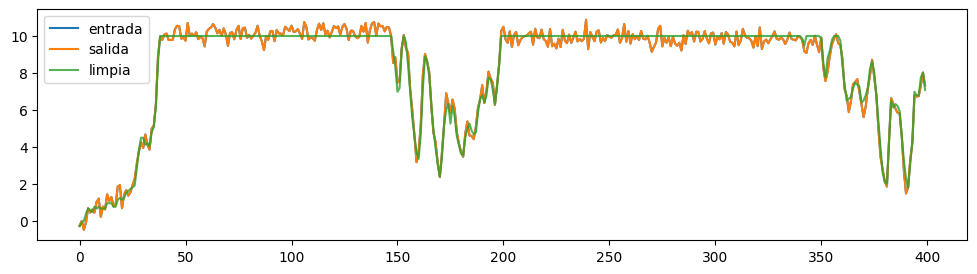

idx=3
message=RESTORE,0.621,0.005,0.423,3.350
reason=intent_detected_and_quality_bad
latency_ms=3.350



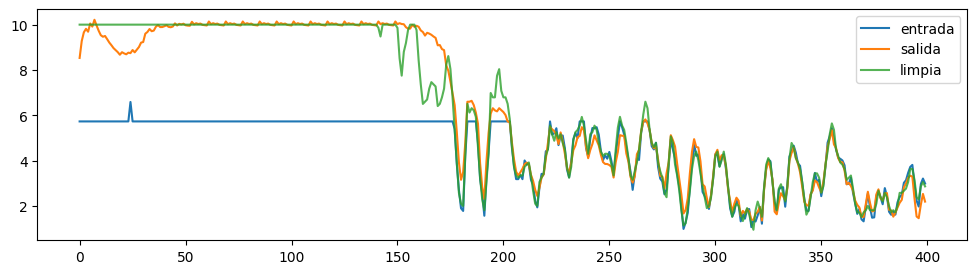

idx=4
message=OK,0.924,1.000,1.000,2.605
reason=signal_quality_good_enough
latency_ms=2.605



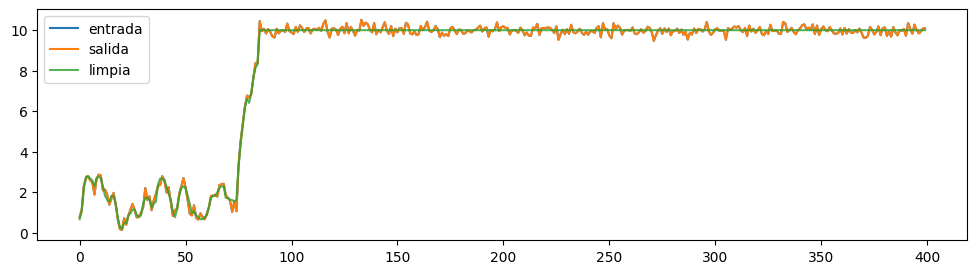

idx=5
message=OK,0.965,1.000,1.000,2.517
reason=signal_quality_good_enough
latency_ms=2.517



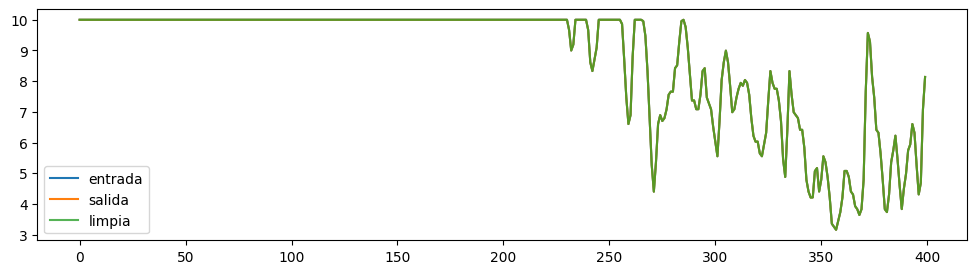

In [16]:
# =========================
# CELDA 15: Ejemplos visuales
# =========================
for i in range(min(6, len(df_stream))):
    row = df_stream.iloc[i]
    print(f"idx={i}")
    print(f"message={row['message']}")
    print(f"reason={row['reason']}")
    print(f"latency_ms={row['latency_ms']:.3f}")
    print()

    plt.figure(figsize=(12,3))
    plt.plot(x_stream[i,0], label="entrada")
    plt.plot(x_out[i,0], label="salida")
    if x_clean_ref is not None:
        plt.plot(x_clean_ref[i,0], label="limpia", alpha=0.8)
    plt.legend()
    plt.show()
